In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Get the Data

Set index_col=0 to use the first column as the index.

In [31]:
df = pd.read_csv("Classified Data",index_col=0)

In [32]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


## Standardize the Variables

Because the KNN classifier predicts the class of a given test observation by identifying the observations that are nearest to it, the scale of the variables matters. Any variables that are on a large scale will have a much larger effect on the distance between the observations, and hence on the KNN classifier, than variables that are on a small scale.

In [33]:
from sklearn.preprocessing import StandardScaler


In [34]:
scaler  = StandardScaler()

In [35]:
scaler.fit(df.drop("TARGET CLASS",axis=1))

,copy,True
,with_mean,True
,with_std,True


In [36]:
scaler_features = scaler.fit_transform(df.drop("TARGET CLASS",axis=1))
df_feat = pd.DataFrame(scaler_features,columns=df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


## Pair Plot

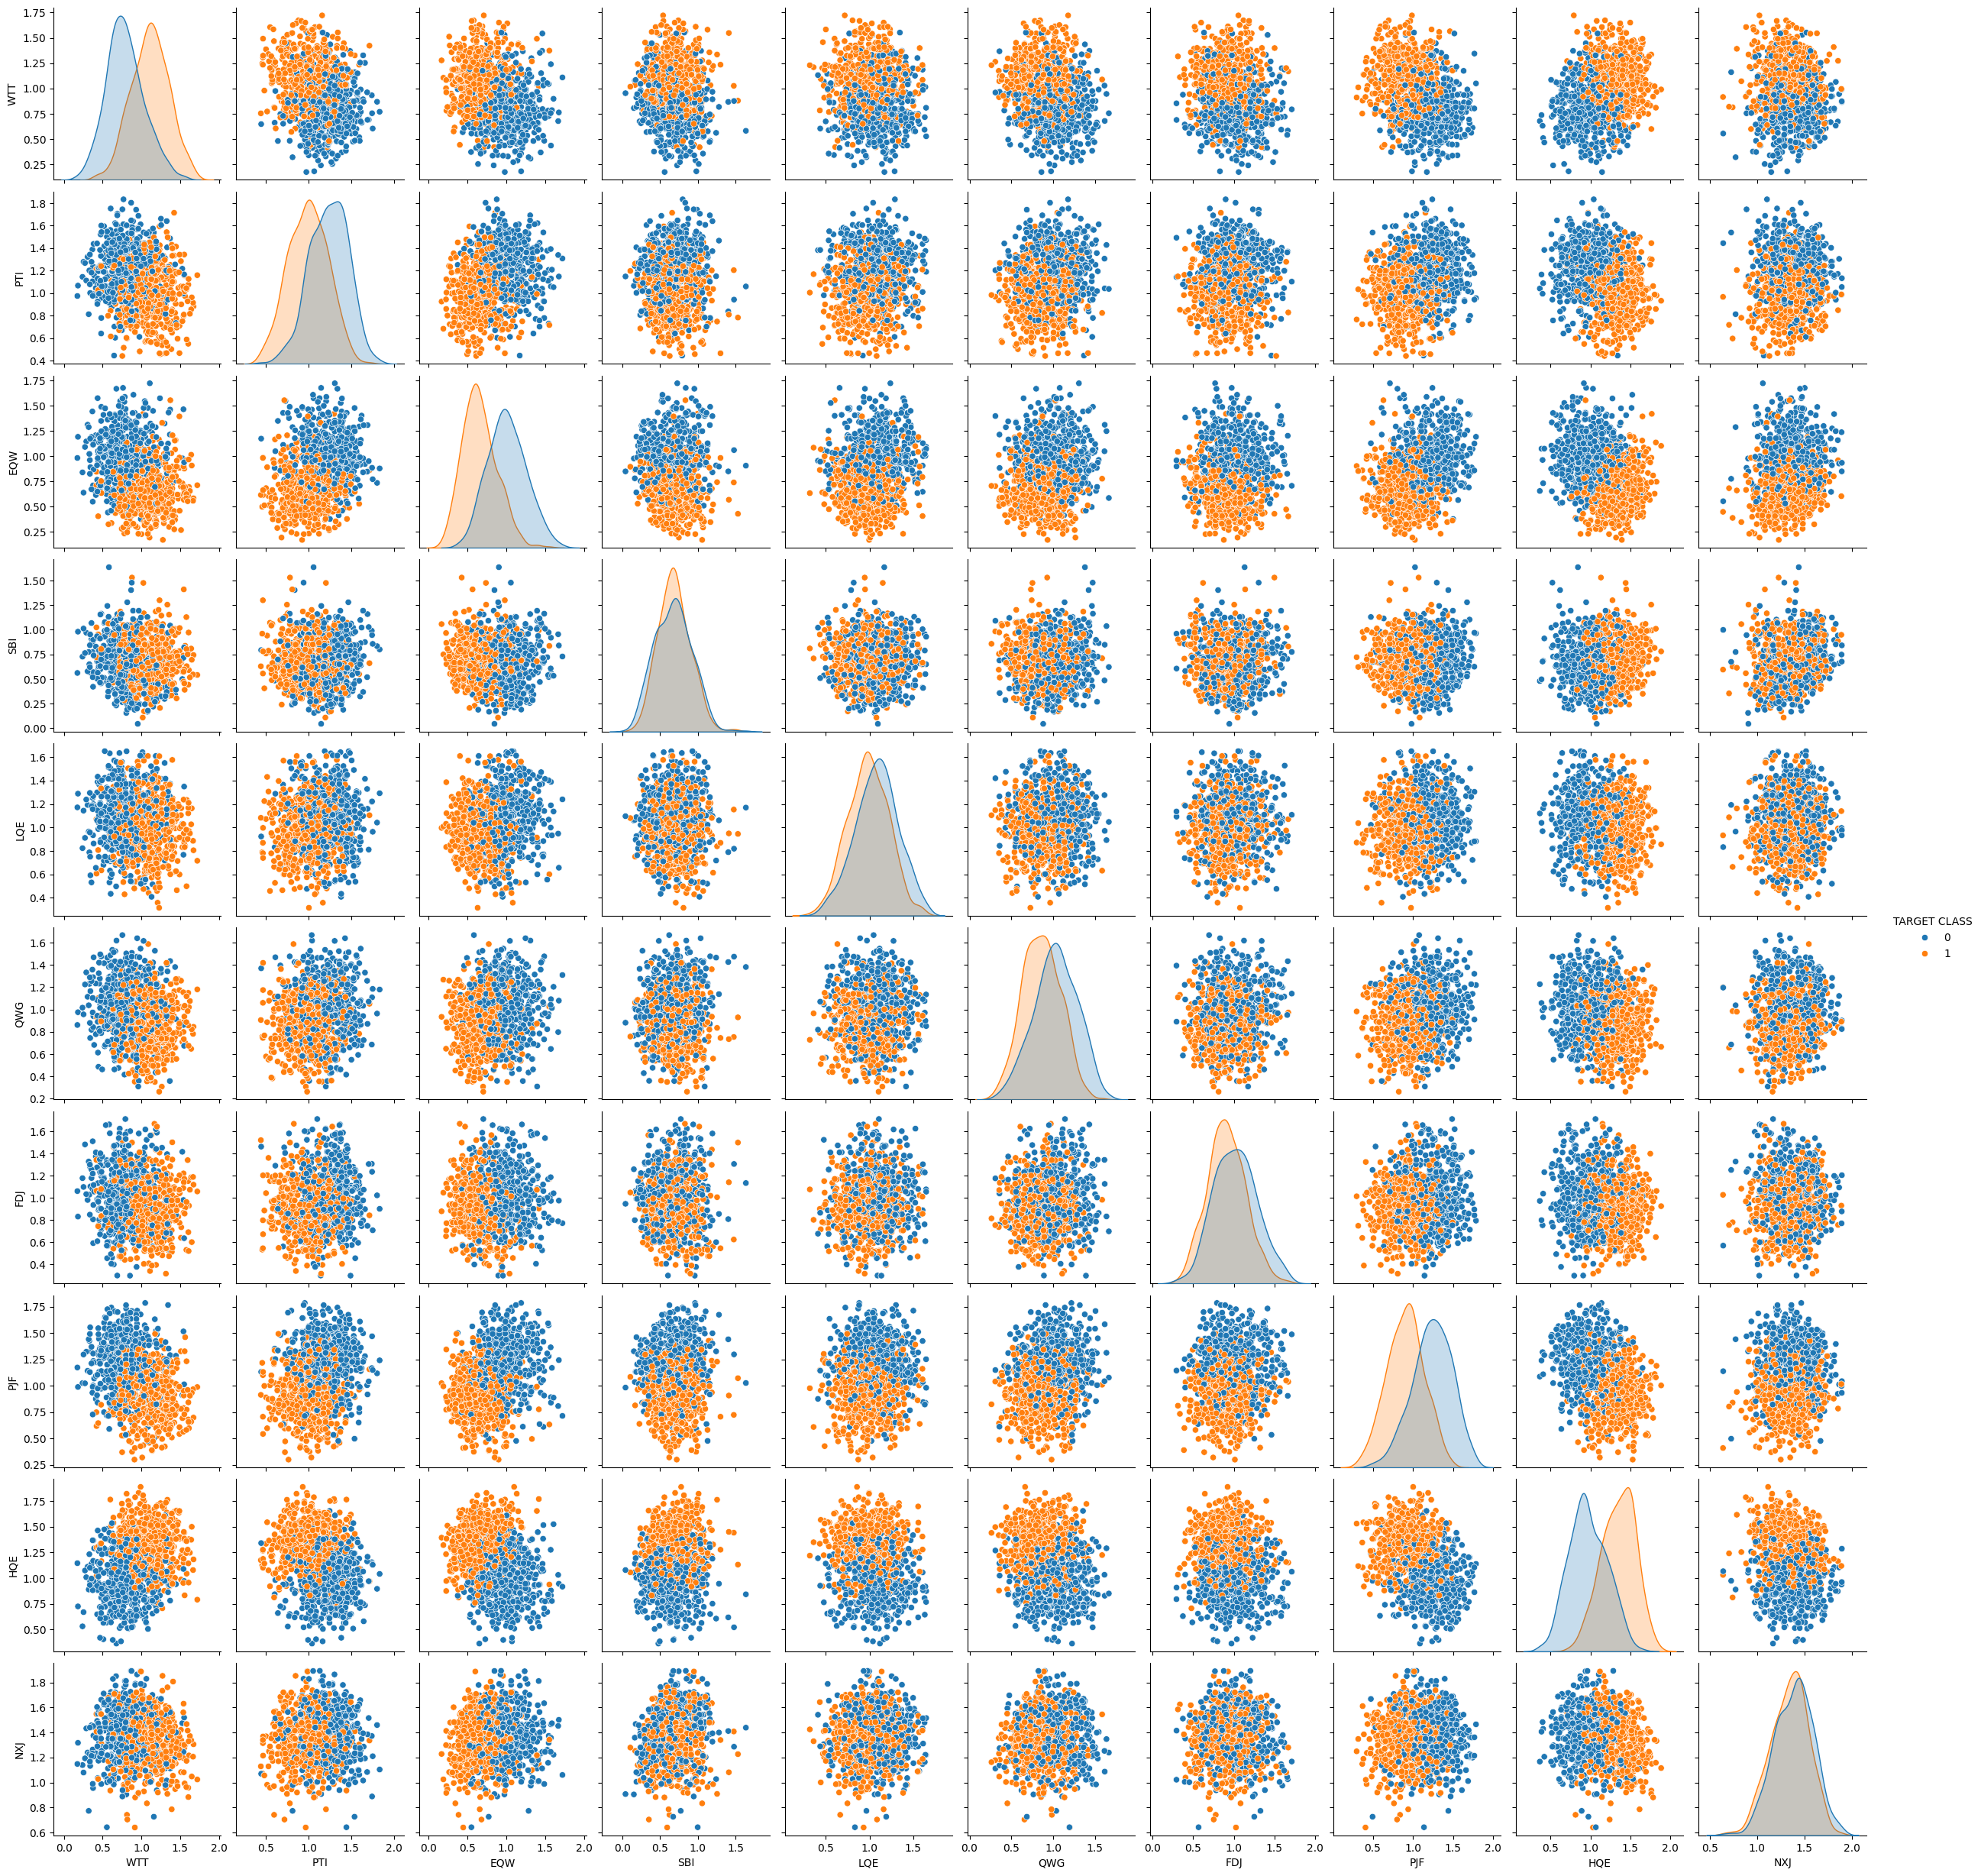

In [37]:
import seaborn as sns
sns.pairplot(df,hue='TARGET CLASS')

## Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(scaler_features,df['TARGET CLASS'],
                                                    test_size=0.30)

## Using KNN

Remember that we are trying to come up with a model to predict whether someone will TARGET CLASS or not. We'll start with k=1.

In [40]:
from sklearn.neighbors import KNeighborsClassifier

In [41]:
knn = KNeighborsClassifier(n_neighbors=1)


In [42]:
knn.fit(X_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
pred = knn.predict(X_test)

## Predictions and Evaluations

Let's evaluate our KNN model!

In [44]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
confusion_matrix(pred,y_test)

array([[138,  10],
       [ 14, 138]])

In [45]:
print(classification_report(pred,y_test))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       148
           1       0.93      0.91      0.92       152

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



## Choosing a K Value

Let's go ahead and use the elbow method to pick a good K Value:

In [57]:
X = df_feat
y = df["TARGET CLASS"]
# Will take some time

accuracy_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    cross_score = cross_val_score(knn,X,y,cv=10)
    accuracy_rate.append(cross_score.mean())

In [58]:
error_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    cross_score = cross_val_score(knn,X,y,cv=5)
    error_rate.append(1-cross_score.mean())

In [67]:
error_rate = []

# Will take some time
for i in range(1,40):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

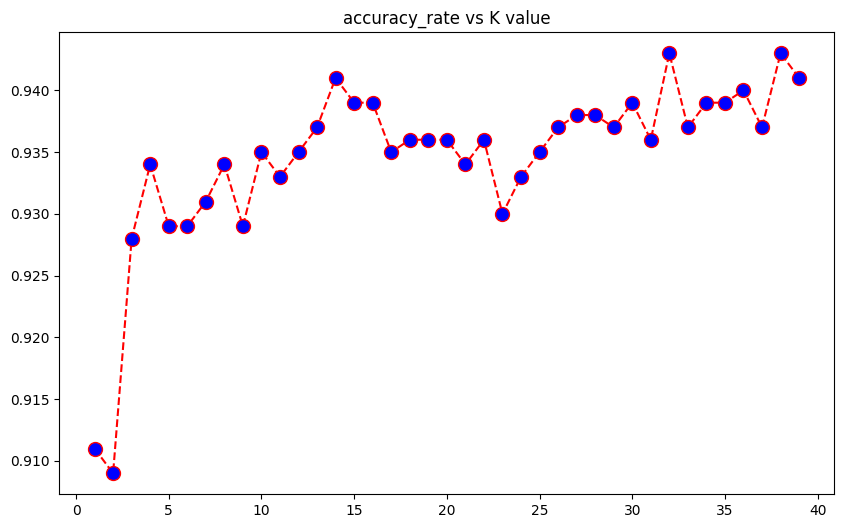

In [59]:
plt.figure(figsize=(10,6))

plt.plot(range(1,40),accuracy_rate,linestyle='dashed',marker='o',color="red",markerfacecolor='blue',markersize=10)
plt.title("accuracy_rate vs K value")
plt.show()

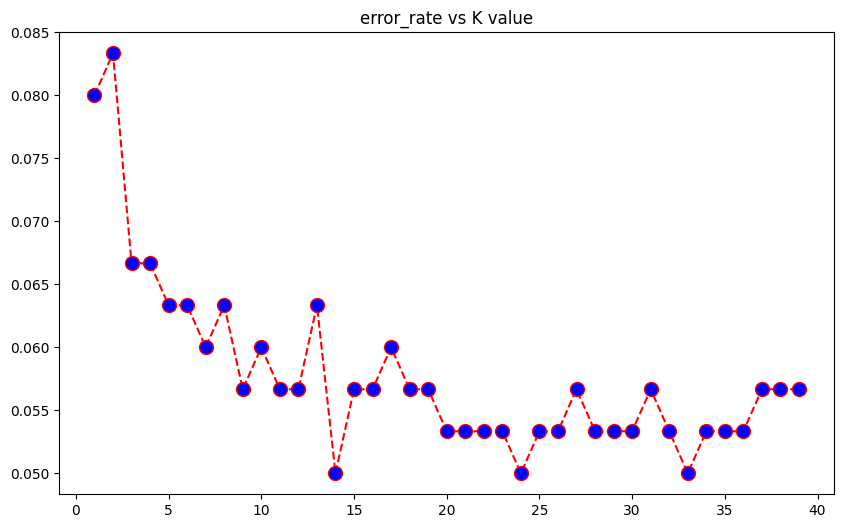

In [68]:
plt.figure(figsize=(10,6))

plt.plot(range(1,40),error_rate,linestyle='dashed',marker='o',color="red",markerfacecolor='blue',markersize=10)
plt.title("error_rate vs K value")
plt.show()

In [69]:
# FIRST A QUICK COMPARISON TO OUR ORIGINAL K=1
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=1


[[138  14]
 [ 10 138]]


              precision    recall  f1-score   support

           0       0.93      0.91      0.92       152
           1       0.91      0.93      0.92       148

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [70]:
# NOW WITH K=23
knn = KNeighborsClassifier(n_neighbors=23)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=23')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=23


[[142  10]
 [  6 142]]


              precision    recall  f1-score   support

           0       0.96      0.93      0.95       152
           1       0.93      0.96      0.95       148

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

